In [2]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))

import datetime
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.spatial import cKDTree
from zhiyi.analysis.SE_analysis import get_site_index



In [3]:
SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"

se_base_files = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
start_date = datetime.date(2018, 6, 22)
end_date = datetime.date(2018, 7, 15)
se_files = []
current = start_date
while current <= end_date:
    MM = current.strftime("%m")
    DD = current.strftime("%d")
    file_path = se_base_files.replace("MM", MM).replace("DD", DD)

    if os.path.exists(file_path):
        se_files.append(file_path)
    else:
        print(f"Warning: File not found - {file_path}, skipping this file.")
    current += datetime.timedelta(days=1)
ds_uk = xr.open_mfdataset(se_files, combine="by_coords")

se_base_files_nobb = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_NOBB_month6/atm/hist/MUSICA_production3.2_NOBB_month6.cam.h2.2018-MM-DD-03600.nc"
start_date_nobb = datetime.date(2018, 6, 22)
end_date_nobb = datetime.date(2018, 7, 2)
se_files_nobb = []
current_nobb = start_date_nobb
while current_nobb <= end_date_nobb:
    MM = current_nobb.strftime("%m")
    DD = current_nobb.strftime("%d")
    file_path_nobb = se_base_files_nobb.replace("MM", MM).replace("DD", DD)

    if os.path.exists(file_path_nobb):
        se_files_nobb.append(file_path_nobb)
    else:
        print(f"Warning: File not found - {file_path_nobb}, skipping this file.")
    current_nobb += datetime.timedelta(days=1)
ds_uk_nobb = xr.open_mfdataset(se_files_nobb, combine="by_coords")

print("Datasets loaded!")

city_lonlat = {
    "Manchester": [360 - 2.237881, 53.481520],
    "Liverpool": [360 - 2.960989, 53.424225],
    "Sheffield": [360 - 1.455815, 53.404950],
    "Birmingham": [360 - 1.874978, 52.476145],
}

Index_lonlat = {}
for city in city_lonlat:
    lon360, lat = city_lonlat[city]
    Index_lonlat[city] = get_site_index(lon360, lat, scrip_file=SCRIP_file)

print("done")


Datasets loaded!
done


In [4]:
cities = [
    "Manchester",
    "Sheffield",
    "Liverpool",
    "Birmingham",
]
vars_model = {"PM2.5": "PM25"}

lon360 = ds_uk["lon"].isel(time=0).values
lat = ds_uk["lat"].isel(time=0).values
lon180 = (lon360 + 180) % 360 - 180

lon360_nb = ds_uk_nobb["lon"].isel(time=0).values
lat_nb = ds_uk_nobb["lat"].isel(time=0).values
lon180_nb = (lon360_nb + 180) % 360 - 180

tree = cKDTree(np.vstack([lat, lon180]).T)
tree_nbb = cKDTree(np.vstack([lat_nb, lon180_nb]).T)
time_bb = pd.to_datetime(ds_uk.time.values)
time_nobb = pd.to_datetime(ds_uk_nobb.time.values)

stats = {city: {} for city in cities}
print("done")
k_cover = 6

for city in cities:
    lon_c360, lat_c = city_lonlat[city]
    lon_c180 = (lon_c360 + 180) % 360 - 180
    _, idx_bb = tree.query([lat_c, lon_c180], k=k_cover)
    _, idx_nb = tree_nbb.query([lat_c, lon_c180], k=k_cover)
    stats[city] = {}
    for name, var in vars_model.items():
        data_bb = ds_uk[var].values
        data_nobb = ds_uk_nobb[var].values
        if name == "AOD":
            arr_bb = data_bb[:, idx_bb]
            arr_nobb = data_nobb[:, idx_nb]
        elif name == "O3":
            o3_bb = data_bb[:, -1, idx_bb] * 1e9
            o3_nobb = data_nobb[:, -1, idx_nb] * 1e9
            t_bb_local = pd.to_datetime(time_bb).tz_localize("UTC").tz_convert("Europe/London")
            t_nobb_local = pd.to_datetime(time_nobb).tz_localize("UTC").tz_convert("Europe/London")

            df_bb = pd.DataFrame(o3_bb, index=t_bb_local)
            df_nobb = pd.DataFrame(o3_nobb, index=t_nobb_local)
            df_bb = df_bb.asfreq("h")
            df_nobb = df_nobb.asfreq("h")
            m8_bb = df_bb.rolling(window=8, min_periods=8).mean()
            m8_nobb = df_nobb.rolling(window=8, min_periods=8).mean()
            mda8_bb = m8_bb.resample("D").max()
            mda8_nobb = m8_nobb.resample("D").max()

            days = mda8_bb.index.intersection(mda8_nobb.index)
            mda8_bb = mda8_bb.loc[days]
            mda8_nobb = mda8_nobb.loc[days]
            time_mda8_bb = mda8_bb.index
            time_mda8_nobb = mda8_nobb.index
            arr_bb = mda8_bb.values
            arr_nobb = mda8_nobb.values
        else:
            arr_bb = data_bb[:, -1, idx_bb] * 1e9
            arr_nobb = data_nobb[:, -1, idx_nb] * 1e9

        stats[city][name] = {
            "mean_bb": np.nanmean(arr_bb, axis=1),
            "mean_nobb": np.nanmean(arr_nobb, axis=1),
        }


done


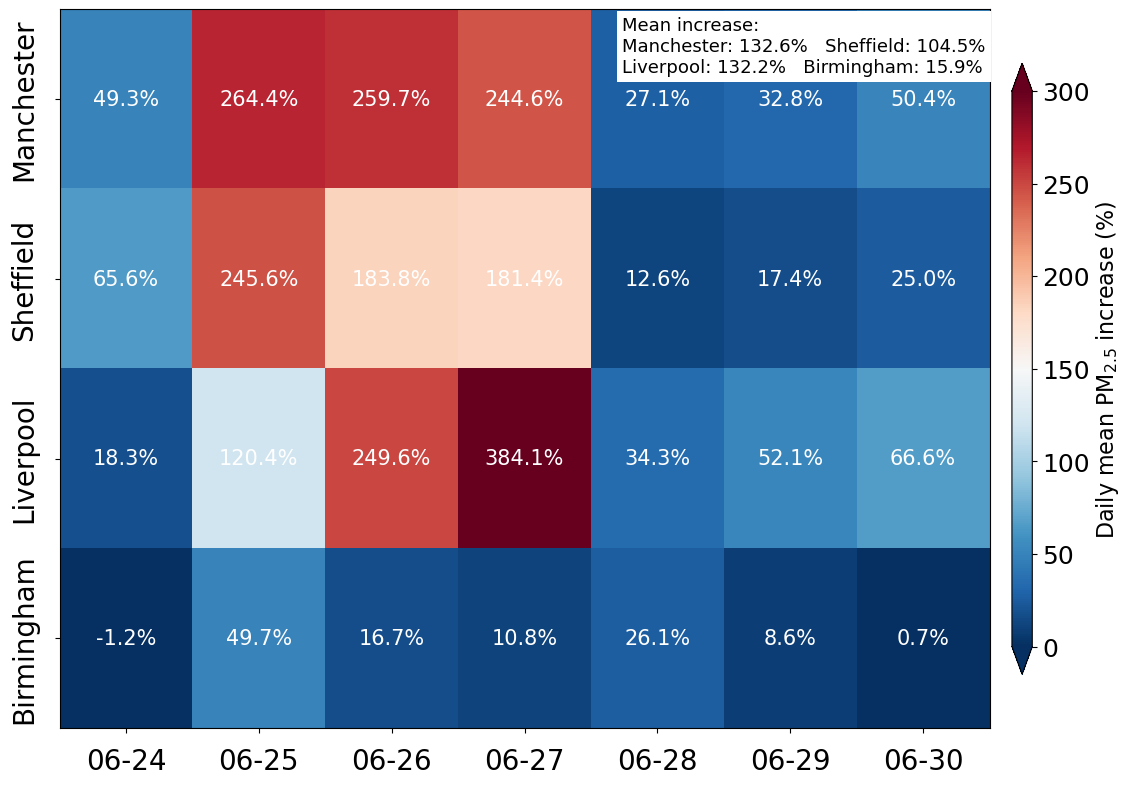

In [16]:
PLOT_START_DATE = "2018-06-24"
PLOT_END_DATE = "2018-06-30"


def build_figure_s17_plot_data(stats, cities, time_bb, time_nobb, start_date=PLOT_START_DATE, end_date=PLOT_END_DATE):
    time_bb_local = pd.to_datetime(time_bb).tz_localize("UTC").tz_convert("Europe/London")
    time_nobb_local = pd.to_datetime(time_nobb).tz_localize("UTC").tz_convert("Europe/London")

    all_days = None
    city_daily_pct = {}

    for city in cities:
        s = stats[city]["PM2.5"]
        mean_bb = np.asarray(s["mean_bb"])
        mean_nobb = np.asarray(s["mean_nobb"])

        ser_bb = pd.Series(mean_bb, index=time_bb_local).asfreq("h")
        ser_nobb = pd.Series(mean_nobb, index=time_nobb_local).asfreq("h")

        daily_bb = ser_bb.resample("D").mean().loc[start_date:end_date]
        daily_nobb = ser_nobb.resample("D").mean().loc[start_date:end_date]

        days = daily_bb.index.intersection(daily_nobb.index)
        daily_bb = daily_bb.loc[days]
        daily_nobb = daily_nobb.loc[days]
        city_daily_pct[city] = 100.0 * (daily_bb - daily_nobb) / daily_nobb
        all_days = days if all_days is None else all_days.intersection(days)

    dates = pd.DatetimeIndex(all_days)
    df_pct = pd.DataFrame(index=cities, columns=dates, dtype=float)

    for city in cities:
        s_pct = city_daily_pct[city].loc[dates]
        df_pct.loc[city, :] = s_pct.values

    mean_per_city = df_pct.mean(axis=1)
    return df_pct, mean_per_city


def plot_figure_s17(df_pct, mean_per_city):
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(df_pct.values.astype(float), aspect="auto", cmap="RdBu_r", vmin=0, vmax=300)

    ax.set_yticks(np.arange(len(df_pct.index)))
    ax.set_yticklabels(df_pct.index, fontsize=20, rotation=90, va="center")
    ax.tick_params(axis="y", pad=12)

    ax.set_xticks(np.arange(len(df_pct.columns)))
    ax.set_xticklabels([pd.Timestamp(d).strftime("%m-%d") for d in df_pct.columns], ha="center", fontsize=20)
    ax.tick_params(axis="x", pad=10)
    # ax.set_xlabel("Date", fontsize=18)

    cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.85, extend="both", aspect=30)
    cbar.ax.tick_params(labelsize=18)
    cbar.set_label("Daily mean PM$_{2.5}$ increase (%)", fontsize=16, labelpad=3)

    for i, city in enumerate(df_pct.index):
        for j, d in enumerate(df_pct.columns):
            val = df_pct.loc[city, d]
            if pd.notna(val):
                ax.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=15, color="white")

    items = [f"{city}: {m:.1f}%" for city, m in mean_per_city.items()]
    mid = len(items) // 2
    line1 = "   ".join(items[:mid])
    line2 = "   ".join(items[mid:])

    mean_text = f"Mean increase:\n{line1}\n{line2}"
    ax.text(
        0.605,
        0.99,
        mean_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        bbox=dict(facecolor="white", alpha=1, edgecolor="none"),
    )

    plt.tight_layout()
    return fig, ax
    
df_pct, mean_per_city = build_figure_s17_plot_data(stats, cities, time_bb, time_nobb)
fig, ax = plot_figure_s17(df_pct, mean_per_city)

In [8]:
figure_data_dir = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data"
figure_s17_nc = os.path.join(figure_data_dir, "FigureS17.nc")
os.makedirs(figure_data_dir, exist_ok=True)

figure_s17_data = xr.Dataset(
    data_vars={
        "pm25_daily_increase_pct": (("city", "date"), df_pct.values.astype(float)),
        "mean_increase_pct": (("city",), mean_per_city.reindex(cities).values.astype(float)),
    },
    coords={
        "city": cities,
        "date": [pd.Timestamp(d).strftime("%Y-%m-%d") for d in df_pct.columns],
    },
    attrs={
        "description": "Figure S17 plotting data generated from original BB and NOBB PM2.5 data",
        "start_date": PLOT_START_DATE,
        "end_date": PLOT_END_DATE,
        "unit": "percent",
    },
)
figure_s17_data.to_netcdf(figure_s17_nc)
figure_s17_nc


'/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS17.nc'

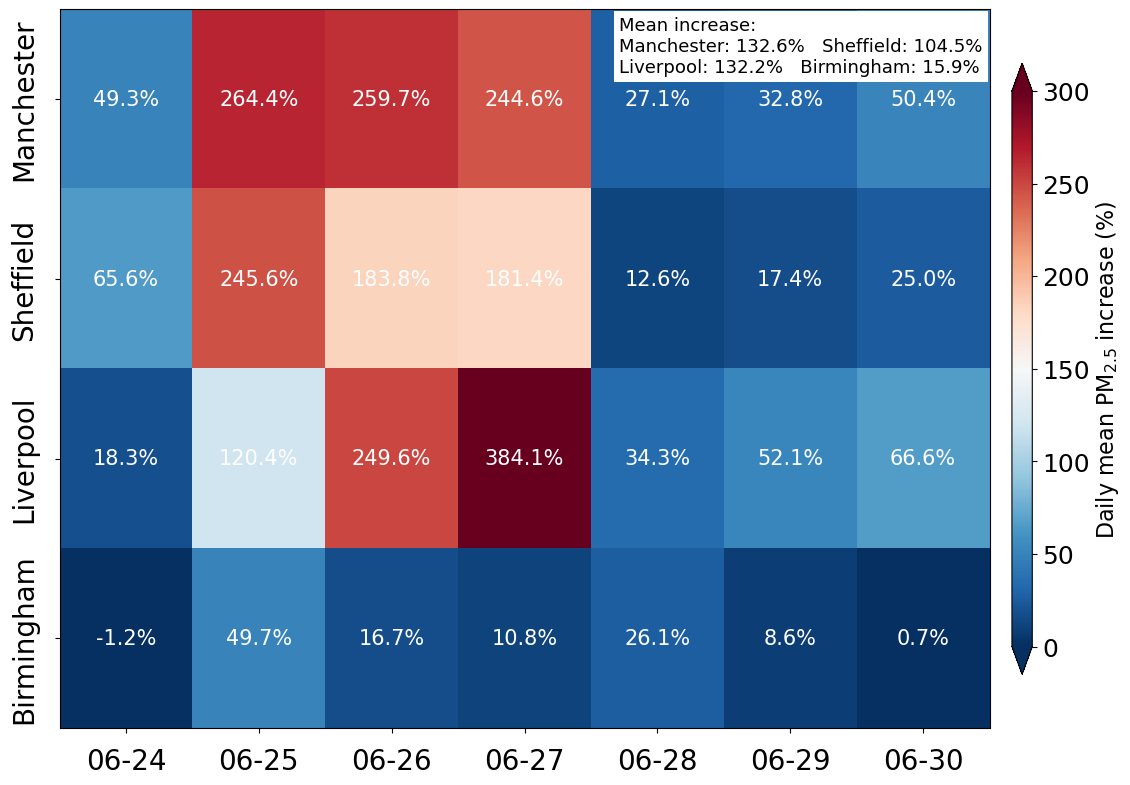

In [ ]:
figure_s17_nc = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS17.nc"
figure_s17_saved = xr.open_dataset(figure_s17_nc)

saved_cities = figure_s17_saved["city"].values.astype(str)
saved_dates = pd.to_datetime(figure_s17_saved["date"].values)
df_pct_saved = pd.DataFrame(
    figure_s17_saved["pm25_daily_increase_pct"].values,
    index=saved_cities,
    columns=saved_dates,
)
mean_per_city_saved = pd.Series(
    figure_s17_saved["mean_increase_pct"].values,
    index=saved_cities,
)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(
    df_pct_saved.values.astype(float),
    aspect="auto",
    cmap="RdBu_r",
    vmin=0,
    vmax=300,
)

ax.set_yticks(np.arange(len(df_pct_saved.index)))
ax.set_yticklabels(df_pct_saved.index, fontsize=20, rotation=90, va="center")
ax.tick_params(axis="y", pad=12)

ax.set_xticks(np.arange(len(df_pct_saved.columns)))
ax.set_xticklabels(
    [pd.Timestamp(d).strftime("%m-%d") for d in df_pct_saved.columns],
    ha="center",
    fontsize=20,
)
ax.tick_params(axis="x", pad=10)
# ax.set_xlabel("Date", fontsize=18)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    shrink=0.85,
    extend="both",
    aspect=30,
)
cbar.ax.tick_params(labelsize=18)
cbar.set_label("Daily mean PM$_{2.5}$ increase (%)", fontsize=16, labelpad=3)

for i, city in enumerate(df_pct_saved.index):
    for j, d in enumerate(df_pct_saved.columns):
        val = df_pct_saved.loc[city, d]
        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=15,
                color="white",
            )

items = [f"{city}: {m:.1f}%" for city, m in mean_per_city_saved.items()]
mid = len(items) // 2
line1 = "   ".join(items[:mid])
line2 = "   ".join(items[mid:])
mean_text = f"Mean increase:\n{line1}\n{line2}"
ax.text(
    0.602,
    0.99,
    mean_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    bbox=dict(facecolor="white", alpha=1, edgecolor="none"),
)

plt.tight_layout()

# from pathlib import Path

# FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures/SI")
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# RASTER_DPI = 300
# png_path = FIGURES_DIR / "FigureS17.png"
# pdf_path = FIGURES_DIR / "FigureS17.pdf"

# fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

# img = plt.imread(png_path)
# height_px, width_px = img.shape[:2]
# pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
# pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
# pdf_ax.imshow(img)
# pdf_ax.axis("off")
# pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
# plt.close(pdf_fig)
# figure_s17_saved.close()
